## Section 1 - Environment Setup and Dependency Installation

In [ ]:
!pip install unsloth -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.4/79.4 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.

## Section 2 — Library Imports, Experimental Reproducibility, and Configuration

In [ ]:
from unsloth import FastLanguageModel

import os
import re
import json
import warnings
import torch
import gc
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
import random
import numpy as np
import matplotlib.patches as mpatches

from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches
from decimal import Decimal, InvalidOperation
from pathlib import Path
from tqdm import tqdm

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Reproducibility Seed Setting

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

transformers.logging.set_verbosity_error()

### Main Folder Setting

In [ ]:
OUTPUTDIR = "/content/drive/MyDrive/Dataset Skripsi/Baseline Evaluation"
CHARTSDIR = os.path.join(OUTPUTDIR, "charts")

os.makedirs(OUTPUTDIR, exist_ok=True)
os.makedirs(CHARTSDIR, exist_ok=True)

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Dataset Skripsi/dataset/test/Full Size Test Set - V3/GSM8K Test Set.json"

### Inference and Chart Static Variable

In [ ]:
ENCOLOR = "#4A90D9"
IDCOLOR = "#E74C3C"
STRATA = ["L1", "L2", "L3"]

MAX_SEQ_LENGTH = 2048
LOAD_IN_4BIT = False

GENERATION_CONFIG = {
    "max_new_tokens": 1024,
    "do_sample": False,
    "use_cache": True,
}

## Section 3 - Utils & Data Preprocessing

In [ ]:
def normalize_number(text):
    """Menormalisasi string jawaban numerik agar bisa dibandingkan secara exact-match pada GSM8K.

    Fungsi ini membersihkan simbol mata uang, satuan kata dalam Bahasa Indonesia,
    dan tanda baca pemisah ribuan, lalu mengonversi hasilnya menjadi representasi
    desimal ternormalisasi (tanpa trailing zero) agar "10.0" dan "10" dianggap sama.

    Args:
        text: Nilai mentah yang akan dinormalisasi. Bisa berupa str, angka, atau None.

    Returns:
        String angka yang sudah dinormalisasi (misal "10.5"), atau string huruf kecil
        dari teks asli jika teks tidak bisa dikonversi ke angka. Mengembalikan None
        jika input adalah None.
    """
    if text is None:
        return None

    text = str(text).strip()

    text = text.replace("$", "")
    text = text.replace("Rp.", "")
    text = text.replace("Rp", "")
    text = text.replace("\,", "")
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.strip().rstrip(".")

    # Pattern: \b...\b memastikan hanya kata utuh yang cocok, (?i) membuat pencarian
    # tidak case-sensitive, dan grup (orang|buah|...) mendaftar satuan yang akan dihapus.
    text = re.sub(r"(?i)\b(orang|buah|kali|rupiah|unit|hari|jam|menit)\b", "", text)
    text = text.strip()

    # Pattern: -?\d+/\d+ mencocokkan pecahan opsional negatif dengan format "pembilang/penyebut".
    if re.fullmatch(r"-?\d+/\d+", text):
        numerator, denominator = text.split("/")
        if denominator != "0":
            value = Decimal(numerator) / Decimal(denominator)
            return format(value.normalize(), "f")

    try:
        value = Decimal(text)
        return format(value.normalize(), "f")
    except (InvalidOperation, ValueError):
        return text.lower()


def extract_answer(text):
    """Mengekstrak jawaban akhir dari teks keluaran model berdasarkan urutan prioritas pattern.

    Prioritas ekstraksi:
    1. Pola \\boxed{...} (format umum pada output reasoning matematika).
    2. Pola "#### ..." (format marker jawaban khas dataset GSM8K).
    3. Angka terakhir yang muncul di teks sebagai fallback jika kedua pola di atas tidak ditemukan.

    Args:
        text: Teks keluaran model yang akan diekstrak jawabannya. Bisa berupa str atau None.

    Returns:
        Tuple (jawaban, metode) di mana jawaban adalah string hasil ekstraksi (atau None
        jika tidak ditemukan) dan metode adalah salah satu dari "boxed", "gsm8k_marker",
        "last_number_fallback", "missing", atau "not_found".
    """
    if text is None:
        return None, "missing"

    text = str(text).strip()

    patterns = [
        # Pattern: \\boxed\{([^{}]+)\} menangkap isi di dalam \boxed{...},
        # dengan [^{}]+ memastikan tidak melintasi kurung kurawal lain di dalamnya.
        (r"\\boxed\{([^{}]+)\}", "boxed"),
        # Pattern: (?im) mengaktifkan mode multiline + case-insensitive, ^\s*####\s*
        # mencocokkan baris yang diawali tanda "####" (dengan spasi opsional),
        # dan ([^\n]+) menangkap sisa teks di baris tersebut sebagai jawaban.
        (r"(?im)^\s*####\s*([^\n]+)", "gsm8k_marker"),
    ]

    for pattern, method in patterns:
        matches = re.findall(pattern, text)

        # Hanya menerima kecocokan yang tidak kosong dan mengandung setidaknya satu digit,
        # untuk menghindari hasil tangkapan yang berupa teks non-numerik.
        valid_matches = [m.strip() for m in matches if m.strip() and re.search(r"\d", m)]
        if valid_matches:
            return valid_matches[-1], method

    # Pattern: -?\d+(?:[.,]\d+)?(?:/\d+)? mencocokkan angka opsional negatif,
    # dengan bagian desimal opsional (dipisah titik atau koma) dan bagian pecahan opsional.
    numbers = re.findall(r"-?\d+(?:[.,]\d+)?(?:/\d+)?", text)
    if numbers:
        return numbers[-1].strip(), "last_number_fallback"

    return None, "not_found"


def is_correct(raw_output, ground_truth):
    """Mengevaluasi apakah jawaban model benar dengan membandingkan hasil normalisasi.

    Fungsi ini mengekstrak jawaban dari output mentah model, menormalisasi jawaban
    tersebut beserta ground truth, lalu membandingkannya secara exact-match.

    Args:
        raw_output: Teks keluaran mentah dari model yang akan dievaluasi.
        ground_truth: Jawaban benar (referensi) untuk dibandingkan.

    Returns:
        Dictionary berisi prediction (jawaban hasil ekstraksi), normalized_prediction,
        normalized_ground_truth, extraction_method (metode ekstraksi yang berhasil),
        dan correct (boolean status kebenaran jawaban).
    """
    prediction, extraction_method = extract_answer(raw_output)

    normalized_prediction = normalize_number(prediction)
    normalized_ground_truth = normalize_number(ground_truth)

    correct = (
        normalized_prediction is not None
        and normalized_prediction == normalized_ground_truth
    )

    return {
        "prediction": prediction,
        "normalized_prediction": normalized_prediction,
        "normalized_ground_truth": normalized_ground_truth,
        "extraction_method": extraction_method,
        "correct": correct,
    }


def clear_vram(model=None, tokenizer=None):
    """Membersihkan objek model dan tokenizer dari memori serta mengosongkan cache VRAM GPU.

    Fungsi ini berguna untuk mencegah kebocoran memori (memory leak) saat melakukan
    eksperimen berulang dengan banyak model pada satu sesi Google Colab atau notebook.

    Args:
        model: Objek model yang akan dihapus dari memori. Opsional, default None.
        tokenizer: Objek tokenizer yang akan dihapus dari memori. Opsional, default None.

    Returns:
        None.
    """
    if model is not None:
        del model
    if tokenizer is not None:
        del tokenizer

    # Memaksa garbage collector Python untuk membebaskan objek yang sudah di-delete.
    gc.collect()

    if torch.cuda.is_available():
        # Mengosongkan cache alokasi memori CUDA yang sudah tidak dipakai agar VRAM
        # yang telah dibebaskan benar-benar bisa digunakan kembali oleh proses lain.
        torch.cuda.empty_cache()

## Section 4 - System Prompts, Dataset Loading & Inference Engine

### Prompts

In [ ]:
SYSTEM_PROMPT_EN = r"""
You are a mathematical reasoning assistant.

Solve the problem carefully, step by step.
On the final line, write only the final numerical answer in this format:
\boxed{value}
"""

SYSTEM_PROMPT_ID = r"""
Anda adalah asisten penalaran matematika.

Selesaikan soal dengan cermat secara bertahap.
Pada baris terakhir, tuliskan hanya jawaban numerik akhir dengan format:
\boxed{nilai}
"""

### Dataset Loading

In [ ]:
# Membuka file dataset dan memuat isinya sebagai struktur data Python (list of dict).
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    raw_dataset = json.load(f)

# Mendefinisikan field wajib yang harus ada pada setiap entri dataset, mencakup
# soal versi Inggris, versi terjemahan, jawaban, dan label strata/tingkat kesulitan.
required_fields = {"question", "translated_question", "answer", "stratum"}

# Memvalidasi setiap entri dataset satu per satu untuk memastikan tidak ada field
# yang hilang, sekaligus melacak indeks entri yang bermasalah untuk debugging.
for idx, item in enumerate(raw_dataset):
    missing = required_fields - set(item.keys())
    if missing:
        raise ValueError(f"Data indeks {idx} tidak memiliki field: {missing}")

# Mengonversi list of dict menjadi DataFrame agar mudah dimanipulasi secara kolumnar.
df_test = pd.DataFrame(raw_dataset)

# Memastikan setiap kolom teks bertipe string dan membersihkan whitespace di awal/akhir,
# untuk mencegah kegagalan pencocokan akibat spasi tersembunyi dari proses translasi/loading.
df_test["question"] = df_test["question"].astype(str).str.strip()
df_test["translated_question"] = df_test["translated_question"].astype(str).str.strip()
df_test["answer"] = df_test["answer"].astype(str).str.strip()
df_test["stratum"] = df_test["stratum"].astype(str).str.strip()

# Memvalidasi bahwa seluruh label stratum yang muncul di dataset merupakan bagian
# dari daftar strata yang telah ditentukan (STRATA), untuk mencegah typo atau label asing.
if not set(df_test["stratum"].unique()).issubset(set(STRATA)):
    raise ValueError(
        f"Strata tidak valid: {sorted(df_test['stratum'].unique())}"
    )

# Mengekstrak masing-masing kolom menjadi list Python terpisah agar mudah diiterasi
# atau dipasangkan (misal saat looping untuk inference per soal).
full_q_en = df_test["question"].tolist()
full_q_id = df_test["translated_question"].tolist()
full_answers = df_test["answer"].tolist()
full_strata = df_test["stratum"].tolist()

### Model Loader

In [ ]:
def load_model_for_inference(model_name):
    """Memuat model dan tokenizer dari Hugging Face/lokal dalam mode siap-inference.

    Fungsi ini menggunakan Unsloth's FastLanguageModel untuk memuat model dengan
    opsi kuantisasi 4-bit, mengaktifkan mode inference (bukan training), dan
    memastikan tokenizer memiliki pad_token yang valid sebelum digunakan.

    Args:
        model_name: Nama atau path model yang akan dimuat, bisa berupa ID model
            Hugging Face Hub atau path lokal ke checkpoint model.

    Returns:
        Tuple (model, tokenizer) yang siap digunakan untuk proses inference.
    """
    # Memuat model dan tokenizer dengan konfigurasi panjang sequence maksimum dan
    # kuantisasi 4-bit False untuk akses full precise model.
    # dtype=None membiarkan Unsloth memilih tipe data optimal secara otomatis.
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=model_name,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=LOAD_IN_4BIT,
    )

    # Mengoptimalkan model untuk mode inference (menonaktifkan komponen yang hanya
    # relevan saat training, seperti gradient checkpointing), sehingga generasi
    # teks berjalan lebih cepat.
    FastLanguageModel.for_inference(model)

    # Beberapa model tidak memiliki pad_token bawaan, sehingga perlu di-fallback
    # ke eos_token agar proses padding saat batching tidak menyebabkan error.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    return model, tokenizer

### Engine

In [ ]:
def run_inference(
    model,
    tokenizer,
    questions,
    system_prompt,
    batch_size=16,
    max_new_tokens=1024,
    desc="Inference",
):
    """Menjalankan inference batch dengan greedy decoding untuk daftar pertanyaan.

    Fungsi ini memproses pertanyaan secara batch menggunakan chat template,
    melakukan generasi teks dengan greedy decoding (deterministik, tanpa sampling),
    lalu memotong output agar hanya menyisakan token hasil generasi (tanpa prompt).
    Padding menggunakan left padding karena posisi awal sequence yang bervariasi
    panjangnya harus disamakan di sisi kiri agar pemotongan berdasarkan panjang
    prompt tetap valid untuk seluruh item dalam batch.

    Args:
        model: Model bahasa yang sudah dimuat dan siap untuk inference.
        tokenizer: Tokenizer yang berpasangan dengan model.
        questions: List string pertanyaan yang akan diproses.
        system_prompt: Instruksi sistem yang disisipkan ke setiap chat template.
        batch_size: Jumlah pertanyaan yang diproses dalam satu batch. Default 16.
        max_new_tokens: Batas maksimum token baru yang digenerate per pertanyaan.
            Default 1024.
        desc: Label deskripsi yang ditampilkan pada progress bar tqdm. Default "Inference".

    Returns:
        List string berisi jawaban hasil generasi model untuk setiap pertanyaan,
        dengan urutan yang sama seperti input questions.
    """
    # Mengatur model ke mode evaluasi agar layer seperti dropout tidak aktif,
    # dan mengatur padding di sisi kiri karena decoder-only model men-generate
    # token baru dari posisi paling kanan sequence.
    model.eval()
    tokenizer.padding_side = "left"

    # Fallback pad_token ke eos_token jika tokenizer belum memilikinya, agar
    # proses padding saat batching tidak menyebabkan error.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    all_outputs = []

    # Memproses pertanyaan per batch (bukan satu-satu) untuk memanfaatkan
    # paralelisme GPU dan mempercepat inference secara keseluruhan.
    for start_idx in tqdm(
        range(0, len(questions), batch_size),
        desc=desc,
    ):
        batch_questions = questions[start_idx : start_idx + batch_size]

        # Membungkus setiap pertanyaan ke dalam format chat (system + user),
        # lalu mengonversinya menjadi string prompt mentah tanpa tokenisasi
        # (tokenize=False), dengan add_generation_prompt=True agar template
        # menyertakan penanda yang memberi sinyal model untuk mulai merespons.
        batch_texts = [
            tokenizer.apply_chat_template(
                [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": question.strip()},
                ],
                tokenize=False,
                add_generation_prompt=True,
            )
            for question in batch_questions
        ]

        # Melakukan tokenisasi batch dengan padding otomatis dan truncation
        # jika melebihi MAX_SEQ_LENGTH, lalu memindahkan tensor ke device
        # yang sama dengan model (GPU/CPU).
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
        ).to(model.device)

        # Menjalankan generasi teks tanpa melacak gradient (inference_mode)
        # untuk menghemat memori dan mempercepat komputasi. do_sample=False
        # membuat decoding bersifat greedy dan deterministik (bukan acak).
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True,
            )

        # Karena left padding, seluruh prompt dalam batch memiliki panjang
        # ter-padding yang sama, sehingga token hasil generasi bisa dipotong
        # secara konsisten mulai dari indeks prompt_length untuk semua item.
        prompt_length = inputs.input_ids.shape[1]
        generated_tokens = outputs[:, prompt_length:]

        # Mendekode token hasil generasi kembali menjadi teks, membuang
        # token spesial (seperti eos_token) agar output bersih.
        decoded_outputs = tokenizer.batch_decode(
            generated_tokens,
            skip_special_tokens=True,
        )

        all_outputs.extend(output.strip() for output in decoded_outputs)

        # Menghapus tensor besar dari memori secara eksplisit setiap batch
        # untuk mencegah akumulasi penggunaan VRAM selama loop berjalan.
        del inputs, outputs, generated_tokens

    return all_outputs

## Section 5 - Evaluation Pipeline

In [ ]:
def evaluate_and_save(
    questions,
    raw_outputs,
    ground_truths,
    strata_list,
    output_prefix,
    language,
    model_name,
    prompt_name,
):
    """Mengevaluasi hasil inference model, menyimpan detail per soal, dan meringkas metrik akurasi.

    Fungsi ini membandingkan setiap output mentah model dengan ground truth menggunakan
    is_correct, menyusun hasilnya menjadi DataFrame, menyimpannya ke tiga format file
    (JSONL, XLSX, CSV), lalu menghitung dan mencetak akurasi keseluruhan, akurasi per
    stratum, serta distribusi metode ekstraksi jawaban yang digunakan.

    Args:
        questions: List pertanyaan yang dievaluasi.
        raw_outputs: List output mentah dari model untuk setiap pertanyaan.
        ground_truths: List jawaban benar (referensi) untuk setiap pertanyaan.
        strata_list: List label stratum/tingkat kesulitan untuk setiap pertanyaan.
        output_prefix: Prefix path file untuk menyimpan hasil (tanpa ekstensi).
        language: Label bahasa soal yang dievaluasi (misal "en" atau "id").
        model_name: Nama model yang dievaluasi, dicatat sebagai metadata pada setiap baris.
        prompt_name: Nama/varian prompt yang digunakan, dicatat sebagai metadata.

    Returns:
        Dictionary berisi accuracy (float akurasi keseluruhan), per_stratum (dict akurasi
        per stratum), extraction_stats (dict persentase metode ekstraksi), dan dataframe
        (DataFrame lengkap hasil evaluasi per soal).

    Raises:
        ValueError: Jika panjang questions, raw_outputs, ground_truths, dan strata_list
            tidak sama.
    """
    # Validasi awal untuk memastikan keempat list saling berpasangan (soal, output,
    # jawaban, stratum) sebelum di-zip, mencegah misalignment data secara diam-diam.
    if not (
        len(questions)
        == len(raw_outputs)
        == len(ground_truths)
        == len(strata_list)
    ):
        raise ValueError("Panjang questions, outputs, answers, dan strata harus sama.")

    records = []

    # Mengevaluasi setiap soal satu per satu menggunakan is_correct, lalu menyusun
    # hasilnya menjadi satu record lengkap berisi metadata (model, bahasa, prompt)
    # dan detail evaluasi (prediksi, normalisasi, metode ekstraksi, status benar/salah).
    for question, raw_output, answer, stratum in zip(
        questions,
        raw_outputs,
        ground_truths,
        strata_list,
    ):
        result = is_correct(raw_output, answer)

        records.append(
            {
                "model": model_name,
                "language": language,
                "prompt_name": prompt_name,
                "question": question,
                "raw_output": raw_output,
                "extracted_answer": result["prediction"],
                "normalized_prediction": result["normalized_prediction"],
                "ground_truth": answer,
                "normalized_ground_truth": result["normalized_ground_truth"],
                "extraction_method": result["extraction_method"],
                "stratum": stratum,
                "correct": result["correct"],
            }
        )

    df_results = pd.DataFrame(records)

    output_jsonl = f"{output_prefix}.jsonl"
    output_xlsx = f"{output_prefix}.xlsx"
    output_csv = f"{output_prefix}.csv"

    # Menyimpan hasil ke tiga format berbeda: JSONL untuk pemrosesan lanjutan/pipeline,
    # XLSX untuk inspeksi manual, dan CSV (dengan encoding utf-8-sig agar kompatibel
    # dibuka di Excel tanpa masalah karakter non-ASCII seperti teks Bahasa Indonesia).
    df_results.to_json(
        output_jsonl,
        orient="records",
        lines=True,
        force_ascii=False,
    )
    df_results.to_excel(output_xlsx, index=False)
    df_results.to_csv(output_csv, index=False, encoding="utf-8-sig")

    # Menghitung akurasi keseluruhan sebagai rata-rata kolom boolean "correct".
    accuracy = df_results["correct"].mean()

    # Menghitung akurasi per stratum, dengan reindex ke STRATA agar stratum yang
    # tidak muncul sama sekali pada batch ini tetap tercatat dengan nilai 0.0
    # (bukan hilang dari hasil), menjaga konsistensi struktur output antar run.
    per_stratum = (
        df_results.groupby("stratum")["correct"]
        .mean()
        .reindex(STRATA, fill_value=0.0)
        .to_dict()
    )

    # Menghitung persentase kemunculan setiap metode ekstraksi (boxed, gsm8k_marker,
    # last_number_fallback, dst) untuk melihat seberapa sering model menghasilkan
    # format jawaban yang diharapkan versus butuh fallback.
    extraction_stats = (
        df_results["extraction_method"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    print(f"\nModel        : {model_name}")
    print(f"Bahasa         : {language}")
    print(f"Prompt         : {prompt_name}")
    print(f"Akurasi        : {accuracy * 100:.2f}%")
    print("Akurasi strata :")
    for stratum, score in per_stratum.items():
        print(f"  {stratum}: {score * 100:.2f}%")

    print("Metode ekstraksi jawaban (%):")
    print(extraction_stats)

    return {
        "accuracy": accuracy,
        "per_stratum": per_stratum,
        "extraction_stats": extraction_stats,
        "dataframe": df_results,
    }

## Part 6 - General Evaluation Model (Instruct)

In [ ]:
# Menetapkan ID model Hugging Face Hub untuk model Qwen2.5-1.5B-Instruct versi
# Unsloth (sudah dioptimasi untuk loading cepat dan kuantisasi 4-bit).
MODEL_GENERAL = "unsloth/Qwen2.5-1.5B-Instruct"
# Menetapkan nama aman (tanpa karakter "/" dari path Hugging Face) untuk digunakan
# sebagai nama folder/file lokal, karena "/" akan diartikan sebagai separator direktori.
SAFE_GENERAL = "Qwen2.5-1.5B-Instruct"

# Membentuk path direktori output khusus untuk model ini di bawah OUTPUTDIR,
# lalu membuat direktori tersebut jika belum ada (exist_ok=True mencegah error
# jika direktori sudah tersedia dari run sebelumnya).
model_dir_general = os.path.join(OUTPUTDIR, SAFE_GENERAL)
os.makedirs(model_dir_general, exist_ok=True)

# Memuat model dan tokenizer Qwen2.5-1.5B-Instruct dalam mode siap-inference
# menggunakan fungsi load_model_for_inference yang sudah didefinisikan sebelumnya.
model_instruct, tokenizer_instruct = load_model_for_inference(MODEL_GENERAL)

==((====))==  Unsloth 2026.8.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

### Indonesian (Instruct)

In [ ]:
# Menjalankan inference batch menggunakan model general (Qwen2.5-1.5B-Instruct)
# pada seluruh pertanyaan versi Bahasa Indonesia (full_q_id), dengan system prompt
# khusus Bahasa Indonesia (SYSTEM_PROMPT_ID) dan konfigurasi generasi yang telah
# ditentukan sebelumnya di GENERATION_CONFIG. Hasilnya adalah list jawaban mentah
# yang belum diekstrak/dinormalisasi, siap dievaluasi lewat evaluate_and_save.
raw_id_general = run_inference(
    model=model_instruct,
    tokenizer=tokenizer_instruct,
    questions=full_q_id,
    system_prompt=SYSTEM_PROMPT_ID,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="General | Indonesia",
)

General | Indonesia: 100%|██████████| 83/83 [42:39<00:00, 30.84s/it]


In [ ]:
# Mengevaluasi hasil inference model general pada soal Bahasa Indonesia, membandingkan
# raw_id_general dengan ground truth full_answers, lalu menyimpan hasilnya ke folder
# model_dir_general dengan prefix "indonesian_id_cot" (menghasilkan file .jsonl, .xlsx,
# dan .csv). Metadata language, model_name, dan prompt_name dicatat untuk membedakan
# hasil ini dari eksperimen lain (bahasa/model/prompt berbeda) saat dianalisis nanti.
res_id_general = evaluate_and_save(
    questions=full_q_id,
    raw_outputs=raw_id_general,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_general, "indonesian_id_cot"),
    language="Bahasa Indonesia",
    model_name=SAFE_GENERAL,
    prompt_name="ID-CoT",
)


Model        : Qwen2.5-1.5B-Instruct
Bahasa         : Bahasa Indonesia
Prompt         : ID-CoT
Akurasi        : 48.60%
Akurasi strata :
  L1: 55.52%
  L2: 43.64%
  L3: 32.00%
Metode ekstraksi jawaban (%):
{'boxed': 59.06, 'last_number_fallback': 40.94}


### English (Instruct)

In [ ]:
# Menjalankan inference batch menggunakan model general (Qwen2.5-1.5B-Instruct)
# pada seluruh pertanyaan versi Bahasa Inggris (full_q_en), dengan system prompt
# khusus Bahasa Inggris (SYSTEM_PROMPT_EN). Hasil ini nantinya dibandingkan dengan
# raw_id_general untuk melihat perbedaan performa model lintas bahasa (EN vs ID)
# pada soal yang secara matematis identik.
raw_en_general = run_inference(
    model=model_instruct,
    tokenizer=tokenizer_instruct,
    questions=full_q_en,
    system_prompt=SYSTEM_PROMPT_EN,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="General | English",
)

General | English: 100%|██████████| 83/83 [38:42<00:00, 27.98s/it]


In [ ]:
# Mengevaluasi hasil inference model general pada soal Bahasa Inggris, membandingkan
# raw_en_general dengan ground truth full_answers (jawaban numerik yang sama dengan
# versi Indonesia, karena nilai matematisnya tidak berubah akibat translasi), lalu
# menyimpan hasilnya ke folder model_dir_general dengan prefix "english_en_cot".
# Hasil ini (res_en_general) nantinya dibandingkan dengan res_id_general untuk
# analisis gap performa lintas bahasa pada model yang sama.
res_en_general = evaluate_and_save(
    questions=full_q_en,
    raw_outputs=raw_en_general,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_general, "english_en_cot"),
    language="Bahasa Inggris",
    model_name=SAFE_GENERAL,
    prompt_name="EN-CoT",
)


Model        : Qwen2.5-1.5B-Instruct
Bahasa         : Bahasa Inggris
Prompt         : EN-CoT
Akurasi        : 67.93%
Akurasi strata :
  L1: 74.46%
  L2: 62.92%
  L3: 53.33%
Metode ekstraksi jawaban (%):
{'boxed': 83.24, 'last_number_fallback': 16.76}


### Save Result

In [ ]:
# Menyiapkan list kosong untuk mengumpulkan ringkasan hasil evaluasi dari seluruh
# model yang akan dievaluasi dalam eksperimen ini (general, merged, SFT, dst).
all_results = []

# Menambahkan ringkasan hasil model general ke all_results, mencakup akurasi
# keseluruhan dan akurasi per stratum untuk kedua bahasa (ID dan EN), sehingga
# nantinya bisa dibandingkan langsung antar model dalam satu tabel/DataFrame.
all_results.append(
    {
        "model": SAFE_GENERAL,
        "precision": "full-size",
        "accuracy_id": res_id_general["accuracy"],
        "accuracy_en": res_en_general["accuracy"],
        "per_stratum_id": res_id_general["per_stratum"],
        "per_stratum_en": res_en_general["per_stratum"],
    }
)

# Membersihkan model_instruct dan tokenizer_instruct dari memori serta mengosongkan
# cache VRAM GPU, agar model berikutnya (misal hasil merging atau SFT) bisa dimuat
# tanpa risiko out-of-memory pada sesi Colab yang VRAM-nya terbatas.
clear_vram(model_instruct, tokenizer_instruct)

## Section 7 - Specialist Model Evaluation (Math-Instruct)

In [ ]:
# Menetapkan ID model Hugging Face Hub untuk Qwen2.5-Math-1.5B-Instruct, varian
# Qwen yang telah dioptimasi khusus untuk kemampuan reasoning matematika, sebagai
# pembanding terhadap model general (SAFE_GENERAL) pada task GSM8K yang sama.
MODEL_MATH = "unsloth/Qwen2.5-Math-1.5B-Instruct"
# Nama aman untuk digunakan sebagai identifier folder/file lokal.
SAFE_MATH = "Qwen2.5-Math-1.5B-Instruct"

# Membentuk dan membuat direktori output khusus untuk model math ini, terpisah
# dari model_dir_general agar hasil kedua model tidak saling menimpa.
model_dir_math = os.path.join(OUTPUTDIR, SAFE_MATH)
os.makedirs(model_dir_math, exist_ok=True)

# Memuat model dan tokenizer Qwen2.5-Math-1.5B-Instruct dalam mode siap-inference.
model_math, tokenizer_math = load_model_for_inference(MODEL_MATH)

==((====))==  Unsloth 2026.8.5: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

### Indonesian (Math)

In [ ]:
# Menjalankan inference batch menggunakan model math (Qwen2.5-Math-1.5B-Instruct)
# pada seluruh pertanyaan versi Bahasa Indonesia (full_q_id). Hasil ini nantinya
# dibandingkan dengan raw_id_general untuk melihat apakah model yang dikhususkan
# untuk matematika (math-specialized) benar-benar unggul dibanding model general
# pada soal GSM8K berbahasa Indonesia, atau justru mengalami degradasi akibat
# fine-tuning matematika yang kemungkinan didominasi data Bahasa Inggris.
raw_id_math = run_inference(
    model=model_math,
    tokenizer=tokenizer_math,
    questions=full_q_id,
    system_prompt=SYSTEM_PROMPT_ID,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="Math | Indonesia",
)

Math | Indonesia: 100%|██████████| 83/83 [1:18:54<00:00, 57.04s/it]


In [ ]:
# Mengevaluasi hasil inference model math pada soal Bahasa Indonesia, membandingkan
# raw_id_math dengan ground truth full_answers, lalu menyimpan hasilnya ke folder
# model_dir_math dengan prefix "indonesian_id_cot". Hasil ini (res_id_math) akan
# dibandingkan langsung dengan res_id_general untuk mengukur apakah spesialisasi
# matematika pada model ini benar-benar meningkatkan akurasi pada soal berbahasa
# Indonesia, atau justru menurun akibat trade-off kapabilitas multibahasa.
res_id_math = evaluate_and_save(
    questions=full_q_id,
    raw_outputs=raw_id_math,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_math, "indonesian_id_cot"),
    language="Bahasa Indonesia",
    model_name=SAFE_MATH,
    prompt_name="ID-CoT",
)


Model        : Qwen2.5-Math-1.5B-Instruct
Bahasa         : Bahasa Indonesia
Prompt         : ID-CoT
Akurasi        : 26.76%
Akurasi strata :
  L1: 32.57%
  L2: 21.40%
  L3: 16.67%
Metode ekstraksi jawaban (%):
{'boxed': 95.07, 'last_number_fallback': 4.25, 'not_found': 0.68}


### English (Math)

In [ ]:
# Menjalankan inference batch menggunakan model math (Qwen2.5-Math-1.5B-Instruct)
# pada seluruh pertanyaan versi Bahasa Inggris (full_q_en), dengan system prompt
# Bahasa Inggris (SYSTEM_PROMPT_EN). Hasil ini menjadi baseline performa "native"
# model math pada bahasa yang kemungkinan besar dominan dalam data fine-tuning-nya,
# sehingga menjadi pembanding penting terhadap raw_id_math untuk mengukur besarnya
# gap performa lintas bahasa pada model yang sama.
raw_en_math = run_inference(
    model=model_math,
    tokenizer=tokenizer_math,
    questions=full_q_en,
    system_prompt=SYSTEM_PROMPT_EN,
    batch_size=16,
    max_new_tokens=GENERATION_CONFIG["max_new_tokens"],
    desc="Math | English",
)

Math | English: 100%|██████████| 83/83 [46:41<00:00, 33.76s/it]


In [ ]:
# Mengevaluasi hasil inference model math pada soal Bahasa Inggris, membandingkan
# raw_en_math dengan ground truth full_answers, lalu menyimpan hasilnya ke folder
# model_dir_math dengan prefix "english_en_cot". Dengan blok ini, keempat kombinasi
# (general x EN, general x ID, math x EN, math x ID) sudah lengkap dan siap untuk
# analisis komparatif gap performa lintas model dan lintas bahasa.
res_en_math = evaluate_and_save(
    questions=full_q_en,
    raw_outputs=raw_en_math,
    ground_truths=full_answers,
    strata_list=full_strata,
    output_prefix=os.path.join(model_dir_math, "english_en_cot"),
    language="Bahasa Inggris",
    model_name=SAFE_MATH,
    prompt_name="EN-CoT",
)


Model        : Qwen2.5-Math-1.5B-Instruct
Bahasa         : Bahasa Inggris
Prompt         : EN-CoT
Akurasi        : 85.67%
Akurasi strata :
  L1: 89.53%
  L2: 84.11%
  L3: 72.67%
Metode ekstraksi jawaban (%):
{'boxed': 98.64, 'last_number_fallback': 1.21, 'not_found': 0.15}


### Save Result

In [ ]:
# Menambahkan ringkasan hasil model math ke all_results, dengan struktur field
# yang identik dengan entri SAFE_GENERAL sebelumnya, agar kedua model bisa
# dibandingkan langsung dalam satu DataFrame/tabel ringkasan nantinya.
all_results.append(
    {
        "model": SAFE_MATH,
        "precision": "full-size",
        "accuracy_id": res_id_math["accuracy"],
        "accuracy_en": res_en_math["accuracy"],
        "per_stratum_id": res_id_math["per_stratum"],
        "per_stratum_en": res_en_math["per_stratum"],
    }
)

# Membersihkan model_math dan tokenizer_math dari memori serta mengosongkan cache
# VRAM GPU, melengkapi siklus load-inference-evaluate-clear untuk model kedua ini,
# sehingga VRAM siap dipakai untuk model berikutnya (misal hasil SLERP merging).
clear_vram(model_math, tokenizer_math)

### Save Baseline Summary

In [ ]:
# Mengonversi all_results (list of dict) menjadi DataFrame agar mudah dianalisis
# dan divisualisasikan secara kolumnar, sekaligus konfirmasi bahwa kolom
# per_stratum_id/per_stratum_en tetap tersimpan sebagai objek dict per baris
# (belum diratakan/flatten menjadi kolom terpisah per stratum).
df_summary = pd.DataFrame(all_results)

# Mengonversi akurasi dari skala desimal (0-1) menjadi persentase (0-100) yang
# lebih mudah dibaca pada tabel dan laporan skripsi, dibulatkan ke 2 desimal.
df_summary["accuracy_id_pct"] = (df_summary["accuracy_id"] * 100).round(2)
df_summary["accuracy_en_pct"] = (df_summary["accuracy_en"] * 100).round(2)
# Menghitung gap performa lintas bahasa (selisih akurasi EN dikurangi ID) untuk
# setiap model, sebagai metrik utama yang mengukur besarnya penurunan/kenaikan
# performa saat model dievaluasi pada soal berbahasa Indonesia dibanding Inggris.
df_summary["cross_lingual_gap_pct"] = (
    df_summary["accuracy_en_pct"] - df_summary["accuracy_id_pct"]
).round(2)

# Menyimpan tabel ringkasan ke CSV dengan encoding utf-8-sig agar kompatibel
# dibuka di Excel tanpa masalah karakter non-ASCII. Nama file diberi suffix
# "_v2" untuk membedakan dari versi sebelumnya (kemungkinan hasil iterasi
# eksperimen yang sudah direvisi).
summary_path = os.path.join(OUTPUTDIR, "baseline_summary_v2.csv")
df_summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

# Menampilkan subset kolom yang relevan untuk perbandingan cepat di notebook:
# nama model, level precision, akurasi kedua bahasa, dan gap lintas bahasa,
# tanpa menampilkan kolom per_stratum yang masih berupa nested dict.
display(
    df_summary[
        [
            "model",
            "precision",
            "accuracy_en_pct",
            "accuracy_id_pct",
            "cross_lingual_gap_pct",
        ]
    ]
)

,model,precision,accuracy_en_pct,accuracy_id_pct,cross_lingual_gap_pct
0,Qwen2.5-1.5B-Instruct,full-size,67.93,48.60,19.33
1,Qwen2.5-Math-1.5B-Instruct,full-size,85.67,26.76,58.91


In [ ]:
def audit_generation_length(raw_outputs, max_new_tokens):
    """Mengaudit distribusi panjang output model untuk mendeteksi generasi yang mencurigakan.

    Fungsi ini menghitung statistik dasar panjang output (dalam jumlah kata) dan
    mengidentifikasi output yang panjangnya mendekati batas max_new_tokens, yang
    biasanya mengindikasikan generasi terpotong (truncated) sebelum model selesai
    merespons secara alami.

    Args:
        raw_outputs: List string berisi output mentah hasil generasi model.
        max_new_tokens: Batas maksimum token baru yang digunakan saat generasi,
            dipakai sebagai acuan ambang kecurigaan (75% dari nilai ini).

    Returns:
        List string berisi output-output yang panjangnya (dalam kata) melebihi
        75% dari max_new_tokens, dianggap berpotensi terpotong.
    """
    # Menghitung panjang setiap output dalam jumlah kata (bukan token), sebagai
    # proksi kasar karena tokenizer asli tidak tersedia di fungsi ini.
    lengths = [len(text.split()) for text in raw_outputs]

    print(f"Jumlah output                : {len(lengths)}")
    print(f"Rata-rata panjang output     : {np.mean(lengths):.2f} kata")
    print(f"Panjang output maksimum      : {np.max(lengths)} kata")

    # Menandai output sebagai "mencurigakan" jika panjangnya (dalam kata) melebihi
    # 75% dari max_new_tokens, karena mendekati batas token biasanya berarti model
    # dihentikan paksa (truncated) sebelum sempat menghasilkan jawaban final/EOS,
    # yang berpotensi merusak proses ekstraksi jawaban di extract_answer.
    suspicious = [
        output for output in raw_outputs
        if len(output.split()) > max_new_tokens * 0.75
    ]

    print(f"Output panjang yang dicurigai: {len(suspicious)}")

    return suspicious

In [ ]:
suspected_truncations = audit_generation_length(
    raw_id_general,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 120.82 kata
Panjang output maksimum      : 499 kata
Output panjang yang dicurigai: 0


In [ ]:
suspected_truncations = audit_generation_length(
    raw_en_general,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 182.10 kata
Panjang output maksimum      : 560 kata
Output panjang yang dicurigai: 0


In [ ]:
suspected_truncations = audit_generation_length(
    raw_id_math,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 224.05 kata
Panjang output maksimum      : 1024 kata
Output panjang yang dicurigai: 14


In [ ]:
suspected_truncations = audit_generation_length(
    raw_en_math,
    GENERATION_CONFIG["max_new_tokens"],
)

Jumlah output                : 1319
Rata-rata panjang output     : 189.35 kata
Panjang output maksimum      : 697 kata
Output panjang yang dicurigai: 0


## Section 8 - Visualize Result

In [ ]:
def format_model_name(model_name):
    return (
        model_name
        .replace("Qwen2.5-", "Qwen2.5 ")
        .replace("-Instruct-4bit", " 1.5B-Instruct")
        .replace("-Math", "-Math")
    )

In [ ]:
def plot_main_baseline_comparison(df_summary):
    """Membuat grouped bar chart perbandingan akurasi model pada Bahasa Inggris dan Indonesia.

    Fungsi ini mengubah df_summary menjadi visualisasi bar chart berkelompok
    (dua bar bersebelahan per model, satu untuk tiap bahasa), menyimpan gambar
    ke CHARTSDIR jika tersedia, dan mengembalikan versi long-format dari data
    yang divisualisasikan untuk keperluan analisis atau tabel lampiran skripsi.

    Args:
        df_summary: DataFrame ringkasan hasil evaluasi, wajib memiliki kolom
            "model", "accuracy_en", dan "accuracy_id" (skala desimal 0-1).

    Returns:
        DataFrame long-format dengan kolom "Model", "Bahasa", dan "Akurasi",
        berisi dua baris per model (satu untuk Bahasa Inggris, satu untuk
        Bahasa Indonesia).
    """
    labels = []
    inggris_scores = []
    indonesia_scores = []
    chart_data = []

    # Mengiterasi setiap baris df_summary untuk mengekstrak nama model yang
    # sudah diformat (format_model_name) dan akurasi kedua bahasa dalam skala
    # persentase, sekaligus menyusun versi long-format ke chart_data untuk
    # dikembalikan sebagai DataFrame terpisah di akhir fungsi.
    for _, row in df_summary.iterrows():
        model_name = format_model_name(row["model"])
        acc_en = row["accuracy_en"] * 100
        acc_id = row["accuracy_id"] * 100

        labels.append(model_name)
        inggris_scores.append(acc_en)
        indonesia_scores.append(acc_id)

        chart_data.append({"Model": model_name, "Bahasa": "Bahasa Inggris", "Akurasi": acc_en})
        chart_data.append({"Model": model_name, "Bahasa": "Bahasa Indonesia", "Akurasi": acc_id})

    # Posisi dasar tiap kelompok bar pada sumbu x, satu posisi per model.
    x = np.arange(len(labels))

    # Lebar tiap bar dan jarak offset dari posisi tengah, agar dua bar (EN/ID)
    # per model tampil bersebelahan tanpa saling tumpang tindih.
    width = 0.34
    offset = 0.19

    # Palet warna baku: oranye terang untuk Bahasa Inggris, oranye gelap untuk
    # Bahasa Indonesia, serta warna teks dan judul yang senada abu-abu netral.
    color_en = '#f2c79e'
    color_id = '#d2691e'
    text_color = '#777777'
    title_color = '#666666'

    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')

    # Menggambar dua set bar: satu digeser ke kiri (-offset) untuk Bahasa
    # Inggris, satu digeser ke kanan (+offset) untuk Bahasa Indonesia, relatif
    # terhadap posisi tengah tiap model pada sumbu x.
    rects1 = ax.bar(x - offset, inggris_scores, width, label='Bahasa Inggris', color=color_en)
    rects2 = ax.bar(x + offset, indonesia_scores, width, label='Bahasa Indonesia', color=color_id)

    # Menyembunyikan garis batas atas dan kanan (gaya minimalis khas chart
    # presentasi), serta memberi warna gelap pada garis batas kiri dan bawah
    # agar sumbu tetap terlihat jelas.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    # Mengatur skala sumbu Y dari 0 hingga 110 dengan interval tick 20, memberi
    # ruang kosong di atas bar tertinggi (maksimum 100%) agar label nilai di
    # atas bar tidak terpotong oleh batas atas grafik.
    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel('Akurasi (%)', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='y', colors=text_color)

    # Menempatkan label nama model pada sumbu X sesuai posisi kelompok bar.
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel('Model', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='x', colors=text_color)

    def autolabel(rects):
        """Menambahkan label nilai persentase di atas setiap bar pada chart.

        Args:
            rects: Koleksi objek bar (hasil ax.bar) yang akan diberi label.

        Returns:
            None.
        """
        for rect in rects:
            height = rect.get_height()
            # Format :.1f menampilkan satu desimal (misal "67.9%") agar label
            # tetap ringkas meski nilai akurasi hasil perkalian mengandung
            # banyak digit desimal.
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, color='black')

    autolabel(rects1)
    autolabel(rects2)

    # Menambahkan judul utama dan subjudul menggunakan fig.text (bukan
    # ax.set_title) agar posisinya bisa diatur presisi secara independen dari
    # area plot, memberi tampilan ala judul-subjudul gaya presentasi.
    fig.text(0.5, 0.96, 'Komparasi Akurasi Keseluruhan', ha='center', va='center',
             fontsize=17, fontweight='bold', color=title_color)
    fig.text(0.5, 0.90, 'General vs Math Instruct', ha='center', va='center',
             fontsize=12, color=text_color)

    # Menempatkan legend di tengah atas, di luar area plot (bbox_to_anchor
    # dengan y > 1), tanpa frame border agar tampilan tetap minimalis.
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False,
              handlelength=1, handleheight=1, labelcolor=text_color, fontsize=11)

    plt.tight_layout()
    # Menyisakan ruang di bagian atas figure (top=0.78) agar judul, subjudul,
    # dan legend yang diposisikan di luar area plot tidak tumpang tindih
    # dengan area chart utama.
    plt.subplots_adjust(top=0.78)

    # Mencoba menyimpan chart ke CHARTSDIR; jika variabel tersebut belum
    # didefinisikan di scope global (NameError), penyimpanan dilewati tanpa
    # menghentikan eksekusi fungsi, sehingga chart tetap bisa ditampilkan.
    try:
        save_path = os.path.join(CHARTSDIR, "baseline_v2_komparasi_utama.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    except NameError:
        pass

    plt.show()

    return pd.DataFrame(chart_data)

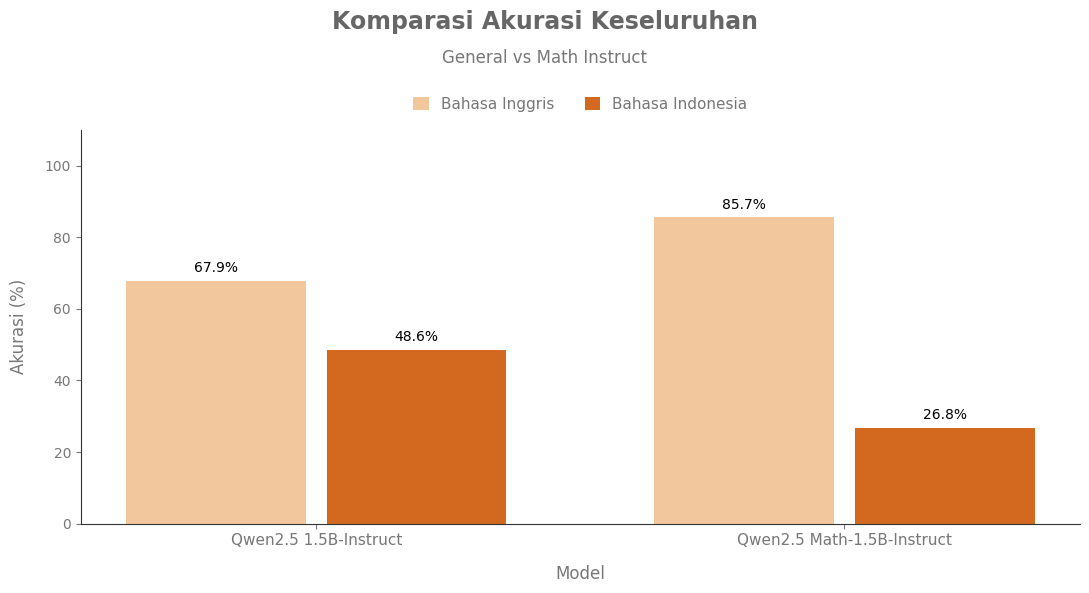

In [ ]:
df_chart_main = plot_main_baseline_comparison(df_summary)

### Visualization Per Strata

In [ ]:
def plot_stratum_comparison(result, model_name, filename):
    """Membuat grouped bar chart perbandingan akurasi per stratum untuk satu model.

    Fungsi ini memvisualisasikan hasil evaluate_and_save untuk satu model
    (result), menampilkan akurasi Bahasa Inggris dan Bahasa Indonesia secara
    berdampingan untuk setiap stratum/tingkat kesulitan pada STRATA, lalu
    menyimpan gambar ke CHARTSDIR dan mengembalikan data long-format-nya.

    Args:
        result: Dictionary hasil evaluate_and_save untuk satu model, wajib
            memiliki key "per_stratum_en" dan "per_stratum_id" (masing-masing
            dict stratum -> akurasi dalam skala desimal 0-1).
        model_name: Nama model yang ditampilkan sebagai subjudul chart.
        filename: Nama file (termasuk ekstensi) untuk menyimpan chart ke CHARTSDIR.

    Returns:
        DataFrame long-format dengan kolom "Strata", "Bahasa", dan "Akurasi",
        berisi dua baris per stratum (satu untuk Bahasa Inggris, satu untuk
        Bahasa Indonesia).
    """
    labels = []
    inggris_scores = []
    indonesia_scores = []
    chart_data = []

    # Mengiterasi STRATA (bukan langsung key dari result) agar urutan stratum
    # pada chart selalu konsisten sesuai definisi global, terlepas dari urutan
    # kemunculannya di dictionary per_stratum_en/per_stratum_id.
    for stratum in STRATA:
        acc_en = result["per_stratum_en"][stratum] * 100
        acc_id = result["per_stratum_id"][stratum] * 100

        labels.append(stratum)
        inggris_scores.append(acc_en)
        indonesia_scores.append(acc_id)

        chart_data.append({"Strata": stratum, "Bahasa": "Bahasa Inggris", "Akurasi": acc_en})
        chart_data.append({"Strata": stratum, "Bahasa": "Bahasa Indonesia", "Akurasi": acc_id})

    # Posisi dasar tiap kelompok bar pada sumbu x, satu posisi per stratum.
    x = np.arange(len(labels))

    # Lebar tiap bar dan jarak offset dari posisi tengah, agar dua bar (EN/ID)
    # per stratum tampil bersebelahan tanpa saling tumpang tindih.
    width = 0.34
    offset = 0.19

    # Palet warna baku: oranye terang untuk Bahasa Inggris, oranye gelap untuk
    # Bahasa Indonesia, serta warna teks dan judul senada abu-abu netral,
    # identik dengan palet pada plot_main_baseline_comparison untuk konsistensi
    # visual antar chart dalam skripsi.
    color_en = '#f2c79e'
    color_id = '#d2691e'
    text_color = '#777777'
    title_color = '#666666'

    fig, ax = plt.subplots(figsize=(11, 6), facecolor='white')

    # Menggambar dua set bar: satu digeser ke kiri (-offset) untuk Bahasa
    # Inggris, satu digeser ke kanan (+offset) untuk Bahasa Indonesia, relatif
    # terhadap posisi tengah tiap stratum pada sumbu x.
    rects1 = ax.bar(x - offset, inggris_scores, width, label='Bahasa Inggris', color=color_en)
    rects2 = ax.bar(x + offset, indonesia_scores, width, label='Bahasa Indonesia', color=color_id)

    # Menyembunyikan garis batas atas dan kanan (gaya minimalis), serta memberi
    # warna gelap pada garis batas kiri dan bawah agar sumbu tetap terlihat jelas.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')

    # Mengatur skala sumbu Y dari 0 hingga 110 dengan interval tick 20, memberi
    # ruang kosong di atas bar tertinggi agar label nilai tidak terpotong.
    ax.set_ylim(0, 110)
    ax.set_yticks(np.arange(0, 120, 20))
    ax.set_ylabel('Akurasi (%)', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='y', colors=text_color)

    # Menempatkan label nama stratum pada sumbu X sesuai posisi kelompok bar.
    ax.set_xticks(x)
    ax.set_xticklabels(labels, color=text_color, fontsize=11)
    ax.set_xlabel('Strata', color=text_color, fontsize=12, labelpad=12)
    ax.tick_params(axis='x', colors=text_color)

    def autolabel(rects):
        """Menambahkan label nilai persentase di atas setiap bar pada chart.

        Args:
            rects: Koleksi objek bar (hasil ax.bar) yang akan diberi label.

        Returns:
            None.
        """
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 4),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=10, color='black')

    autolabel(rects1)
    autolabel(rects2)

    # Menambahkan judul utama tetap ("Akurasi per Strata") dan subjudul dinamis
    # berupa model_name, agar chart ini bisa dibedakan antar model saat dibuat
    # berulang kali untuk model general, math, dan hasil merging.
    fig.text(0.5, 0.96, 'Akurasi per Strata', ha='center', va='center',
             fontsize=17, fontweight='bold', color=title_color)
    fig.text(0.5, 0.90, model_name, ha='center', va='center',
             fontsize=12, color=text_color)

    # Menempatkan legend di tengah atas, di luar area plot, tanpa frame border
    # agar tampilan tetap minimalis dan konsisten dengan chart lainnya.
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False,
              handlelength=1, handleheight=1, labelcolor=text_color, fontsize=11)

    plt.tight_layout()
    # Menyisakan ruang di bagian atas figure agar judul, subjudul, dan legend
    # yang diposisikan di luar area plot tidak tumpang tindih dengan chart utama.
    plt.subplots_adjust(top=0.78)

    # Mencoba menyimpan chart ke CHARTSDIR dengan nama file yang diberikan
    # sebagai parameter (berbeda untuk setiap model); jika CHARTSDIR belum
    # didefinisikan, penyimpanan dilewati dan diberi pesan info tanpa
    # menghentikan eksekusi fungsi, sehingga chart tetap bisa ditampilkan.
    try:
        save_path = os.path.join(CHARTSDIR, filename)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    except NameError:
        print(f"Info: Gambar belum disimpan karena CHARTSDIR tidak ditemukan, tapi bisa ditampilkan.")

    plt.show()

    return pd.DataFrame(chart_data)

In [ ]:
result_general = all_results[0]
result_math = all_results[1]

### General Model (Instruct)

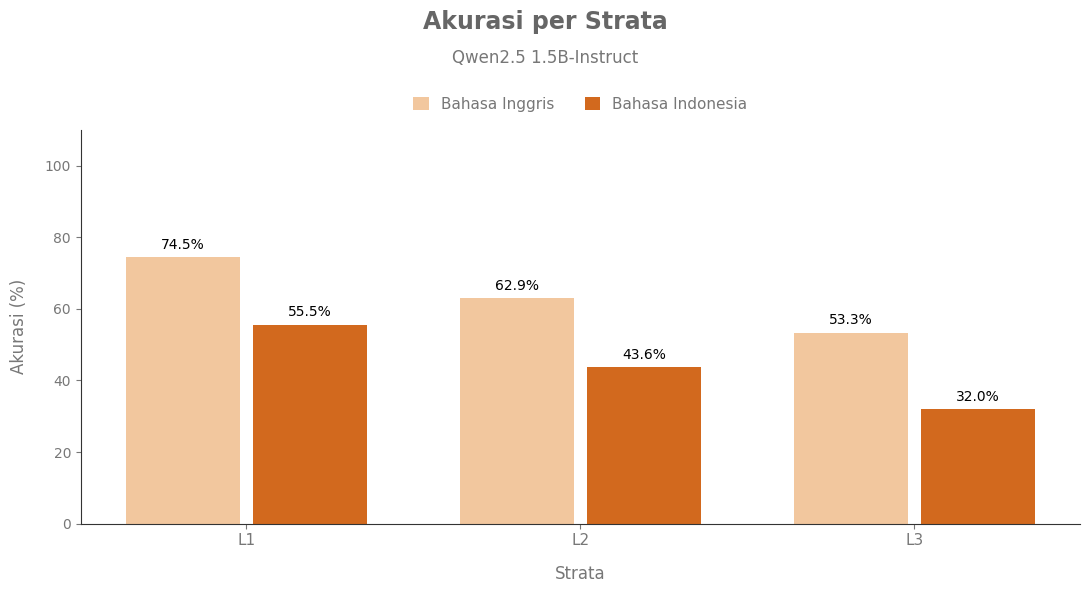

In [ ]:
df_chart_general = plot_stratum_comparison(
    result=result_general,
    model_name="Qwen2.5 1.5B-Instruct",
    filename="baseline_v2_strata_general.png",
)

### General Model (Instruct)

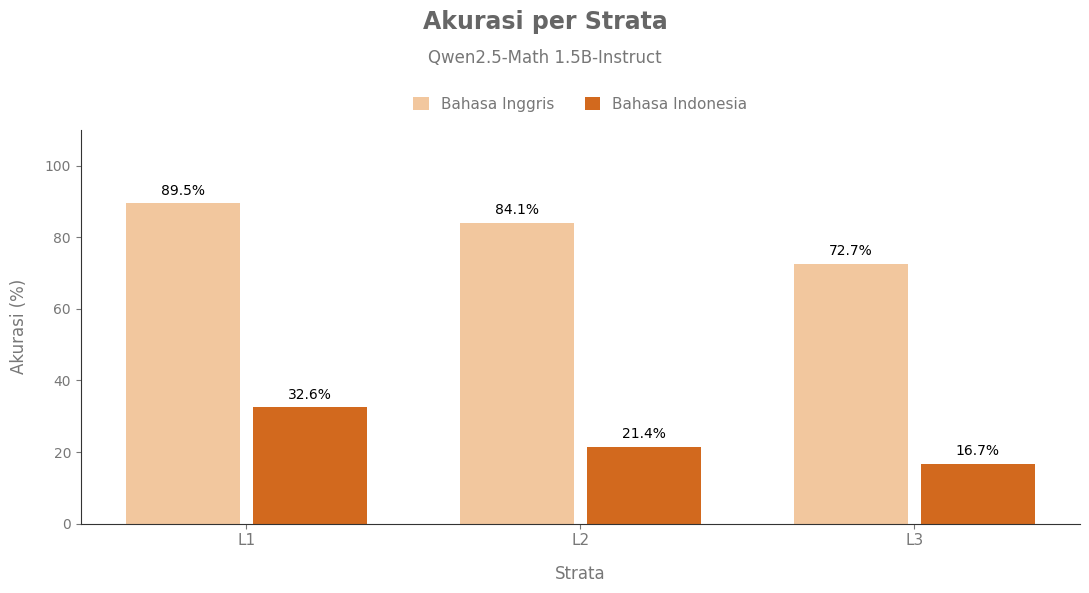

In [ ]:
df_chart_math = plot_stratum_comparison(
    result=result_math,
    model_name="Qwen2.5-Math 1.5B-Instruct",
    filename="baseline_v2_strata_math.png",
)